In [1]:
%matplotlib inline

In [2]:

import sys, os, warnings
warnings.filterwarnings('ignore')

# Ensure src/ is importable
sys.path.insert(0, os.path.join('..', 'src'))

import re
from collections import Counter

import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.dates   as mdates
import seaborn            as sns
from sklearn.feature_extraction.text import TfidfVectorizer

from eda_utils import (
    load_news_data, headline_stats, articles_per_publisher,
    extract_domain, publisher_domains, top_keywords,
    monthly_volume, hourly_volume, day_of_week_volume,
    data_quality_report,
)




In [3]:
# ── Styling ───────────────────────────────────────────────────────────────────
PALETTE = '#1a1a2e #16213e #0f3460 #e94560 #533483 #2ecc71 #f39c12'.split()
sns.set_theme(style='darkgrid', palette=PALETTE)
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#1a1a2e',
    'axes.edgecolor':   '#444',
    'axes.labelcolor':  'white',
    'xtick.color':      '#aaa',
    'ytick.color':      '#aaa',
    'text.color':       'white',
    'grid.color':       '#2a2a3e',
    'grid.linewidth':    0.6,
    'font.family':      'DejaVu Sans',
})

In [4]:
DATA_PATH = '../data/raw/raw_analyst_ratings.csv'
df = load_news_data(DATA_PATH)

print(f'Dataset shape : {df.shape} ')
df.head(5)

Dataset shape : (1407328, 11) 


,Unnamed: 0,headline,url,publisher,date,stock,headline_len,hour,day_of_week,year_month,date_only
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54,A,39,10,Friday,2020-06,2020-06-05
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20,A,42,10,Wednesday,2020-06,2020-06-03
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07,A,29,4,Tuesday,2020-05,2020-05-26
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06,A,44,12,Friday,2020-05,2020-05-22
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59,A,87,11,Friday,2020-05,2020-05-22


In [5]:

# Data quality report
qr = data_quality_report(df)
print('\n── Data Quality Report ──')
print(qr.to_string())


── Data Quality Report ──
                       dtype  missing  missing%   unique
Unnamed: 0             int64        0       0.0  1407328
headline                 str        0       0.0   845770
url                      str        0       0.0   883429
publisher                str        0       0.0     1034
date          datetime64[us]        0       0.0    39957
stock                    str        0       0.0     6204
headline_len           int64        0       0.0      360
hour                   int32        0       0.0       24
day_of_week              str        0       0.0        7
year_month         period[M]        0       0.0      136
date_only     datetime64[us]        0       0.0     3955


In [6]:
# Dataset summary
print('Date range  :', df['date'].min().date(), '→', df['date'].max().date())
print('Stocks      :', sorted(df['stock'].unique()))
print('Publishers  :', df['publisher'].nunique(), 'unique')
print('Articles    :', len(df))


Date range  : 2009-02-14 → 2020-06-11
Stocks      : ['A', 'AA', 'AAC', 'AADR', 'AAL', 'AAMC', 'AAME', 'AAN', 'AAOI', 'AAON', 'AAP', 'AAPL', 'AAU', 'AAV', 'AAVL', 'AAWW', 'AAXJ', 'AB', 'ABAC', 'ABAX', 'ABB', 'ABBV', 'ABC', 'ABCB', 'ABCD', 'ABCO', 'ABCW', 'ABDC', 'ABEV', 'ABG', 'ABGB', 'ABIO', 'ABM', 'ABMD', 'ABR', 'ABTL', 'ABX', 'ABY', 'ACAD', 'ACAS', 'ACAT', 'ACC', 'ACCO', 'ACCU', 'ACE', 'ACET', 'ACFC', 'ACFN', 'ACG', 'ACGL', 'ACH', 'ACHC', 'ACHN', 'ACIW', 'ACLS', 'ACM', 'ACMP', 'ACN', 'ACNB', 'ACOR', 'ACP', 'ACPW', 'ACRE', 'ACRX', 'ACSF', 'ACST', 'ACT', 'ACTA', 'ACTG', 'ACTS', 'ACU', 'ACUR', 'ACWI', 'ACWV', 'ACWX', 'ACXM', 'ACY', 'ADAT', 'ADBE', 'ADC', 'ADEP', 'ADES', 'ADGE', 'ADHD', 'ADI', 'ADK', 'ADM', 'ADMA', 'ADMP', 'ADMS', 'ADNC', 'ADP', 'ADPT', 'ADRA', 'ADRD', 'ADRE', 'ADRU', 'ADS', 'ADSK', 'ADT', 'ADTN', 'ADVS', 'ADX', 'ADXS', 'ADZ', 'AE', 'AEB', 'AEC', 'AEE', 'AEG', 'AEGN', 'AEGR', 'AEHR', 'AEIS', 'AEL', 'AEM', 'AEO', 'AEPI', 'AER', 'AERI', 'AES', 'AET', 'AETI', 'AEY', 'AEZS',

In [7]:
stats = headline_stats(df)
print('Headline Length Statistics')
print(stats.round(2).to_string())

Headline Length Statistics
count    1407328.00
mean          73.12
std           40.74
min            3.00
25%           47.00
50%           64.00
75%           87.00
max          512.00


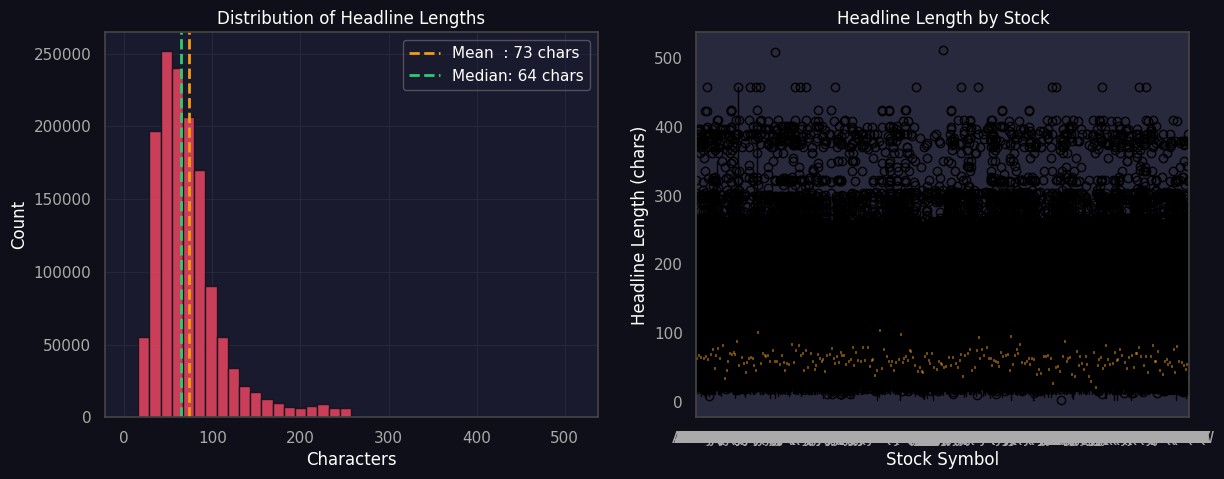

In [8]:
# Figure 1 — Headline Length
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(df['headline_len'], bins=40, color='#e94560', edgecolor='#0f0f1a', alpha=0.85)
ax.axvline(df['headline_len'].mean(),   color='#f39c12', lw=2, ls='--',
           label=f'Mean  : {df["headline_len"].mean():.0f} chars')
ax.axvline(df['headline_len'].median(), color='#2ecc71', lw=2, ls='--',
           label=f'Median: {df["headline_len"].median():.0f} chars')
ax.set_xlabel('Characters'); ax.set_ylabel('Count')
ax.set_title('Distribution of Headline Lengths')
ax.legend(framealpha=0.3)

ax = axes[1]
stocks_sorted = sorted(df['stock'].unique())
bp = ax.boxplot(
    [df[df['stock']==s]['headline_len'] for s in stocks_sorted],
    labels=stocks_sorted, patch_artist=True,
    medianprops=dict(color='#f39c12', lw=2)
)
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.8)
ax.set_xlabel('Stock Symbol'); ax.set_ylabel('Headline Length (chars)')
ax.set_title('Headline Length by Stock')

plt.show()


In [9]:
pub_counts = articles_per_publisher(df, top_n=12)
print('Top 12 Publishers:')
print(pub_counts.to_string())

Top 12 Publishers:
publisher
Paul Quintaro        228373
Lisa Levin           186979
Benzinga Newsdesk    150484
Charles Gross         96732
Monica Gerson         82380
Eddie Staley          57254
Hal Lindon            49047
ETF Professor         28489
Juan Lopez            28438
Benzinga Staff        28114
Vick Meyer            24826
webmaster             20313


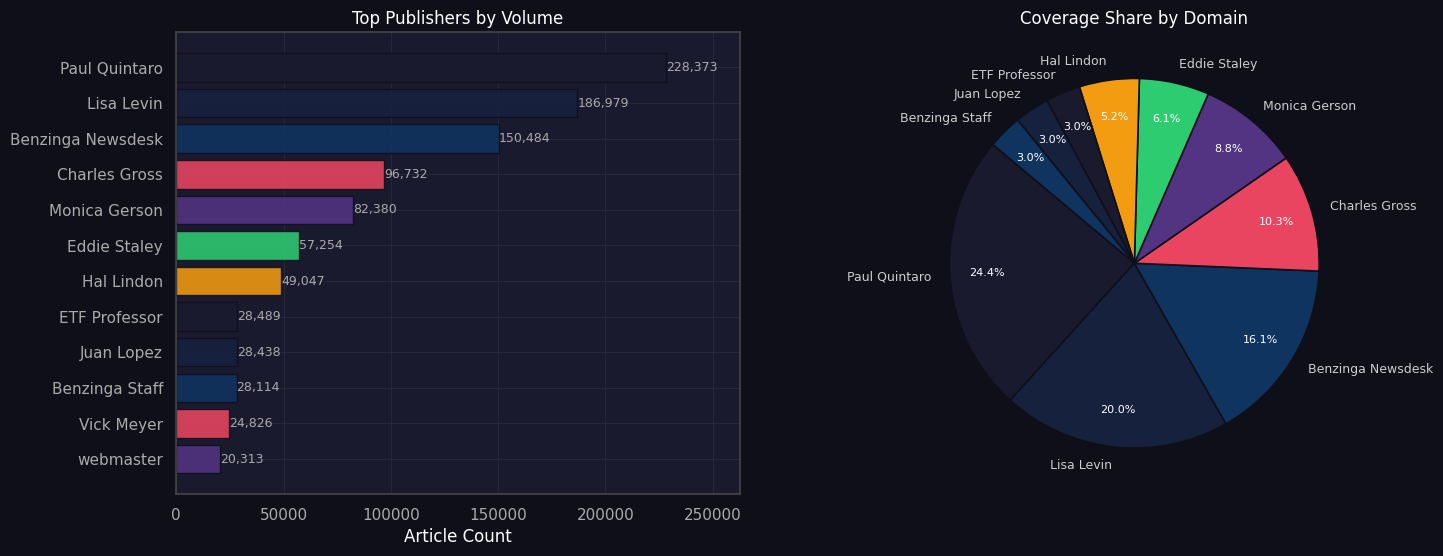

In [10]:
df['domain'] = df['publisher'].apply(extract_domain)
domain_counts = publisher_domains(df).head(10)

# Figure 2 — Publisher Analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
colors = [PALETTE[i % len(PALETTE)] for i in range(len(pub_counts))]
bars = ax.barh(pub_counts.index[::-1], pub_counts.values[::-1], color=colors[::-1], alpha=0.88, edgecolor='#0f0f1a')
for bar, val in zip(bars, pub_counts.values[::-1]):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#aaa')
ax.set_xlabel('Article Count'); ax.set_title('Top Publishers by Volume')
ax.set_xlim(0, pub_counts.max() * 1.15)

ax = axes[1]
wedges, texts, autotexts = ax.pie(
    domain_counts.values, labels=domain_counts.index,
    autopct='%1.1f%%', colors=PALETTE[:len(domain_counts)],
    startangle=140, pctdistance=0.8,
    wedgeprops=dict(edgecolor='#0f0f1a', linewidth=1.2)
)
for t in autotexts: t.set_color('white'); t.set_fontsize(8)
for t in texts:     t.set_color('#ccc');  t.set_fontsize(9)
ax.set_title('Coverage Share by Domain')

plt.show()



In [11]:
monthly_all = monthly_volume(df)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# All stocks
ax = axes[0]
ax.fill_between(monthly_all['year_month_dt'], monthly_all['count'], alpha=0.4, color='#e94560')
ax.plot(monthly_all['year_month_dt'], monthly_all['count'], color='#e94560', lw=2)
peak_idx = monthly_all['count'].idxmax()
peak_row = monthly_all.iloc[peak_idx]
ax.annotate(f"Peak: {peak_row['count']} articles",
            xy=(peak_row['year_month_dt'], peak_row['count']),
            xytext=(30, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='#f39c12'),
            color='#f39c12', fontsize=10)
ax.set_ylabel('Articles / Month'); ax.set_title('Monthly Volume — All Stocks')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')

# Per stock
ax = axes[1]
for i, stock in enumerate(sorted(df['stock'].unique())):
    sdf = monthly_volume(df, stock=stock)
    ax.plot(sdf['year_month_dt'], sdf['count'], label=stock, color=PALETTE[i % len(PALETTE)], lw=1.8, alpha=0.9)
ax.set_xlabel('Date'); ax.set_ylabel('Articles / Month')
ax.set_title('Monthly Volume by Stock Symbol')
ax.legend(loc='upper left', framealpha=0.3, ncol=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')

plt.show()



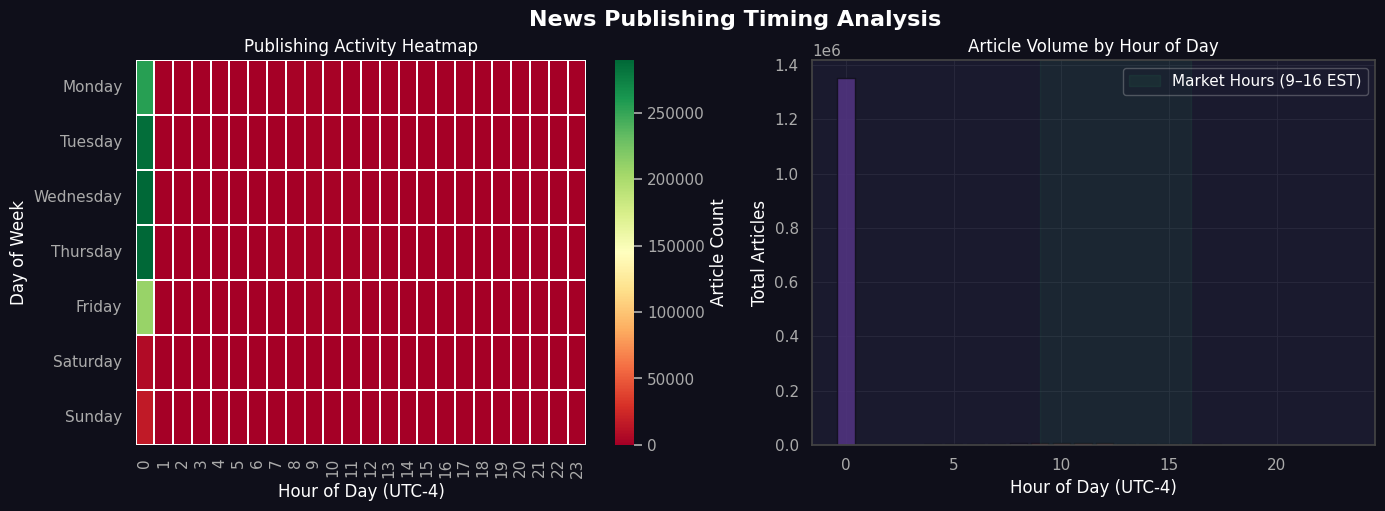

In [12]:
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat_data = df.groupby(['day_of_week','hour']).size().unstack(fill_value=0)
heat_data = heat_data.reindex([d for d in DOW_ORDER if d in heat_data.index])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('News Publishing Timing Analysis', fontsize=16, fontweight='bold', color='white')

ax = axes[0]
sns.heatmap(heat_data, ax=ax, cmap='RdYlGn', linewidths=0.3,
            cbar_kws={'label':'Article Count'}, annot=False)
ax.set_xlabel('Hour of Day (UTC-4)'); ax.set_ylabel('Day of Week')
ax.set_title('Publishing Activity Heatmap')

ax = axes[1]
hourly = hourly_volume(df)
colors = ['#e94560' if (9 <= h <= 16) else '#533483' for h in hourly.index]
ax.bar(hourly.index, hourly.values, color=colors, alpha=0.85, edgecolor='#0f0f1a')
ax.set_xlabel('Hour of Day (UTC-4)'); ax.set_ylabel('Total Articles')
ax.set_title('Article Volume by Hour of Day')
ax.axvspan(9, 16, alpha=0.07, color='#2ecc71', label='Market Hours (9–16 EST)')
ax.legend(framealpha=0.3)

plt.show()


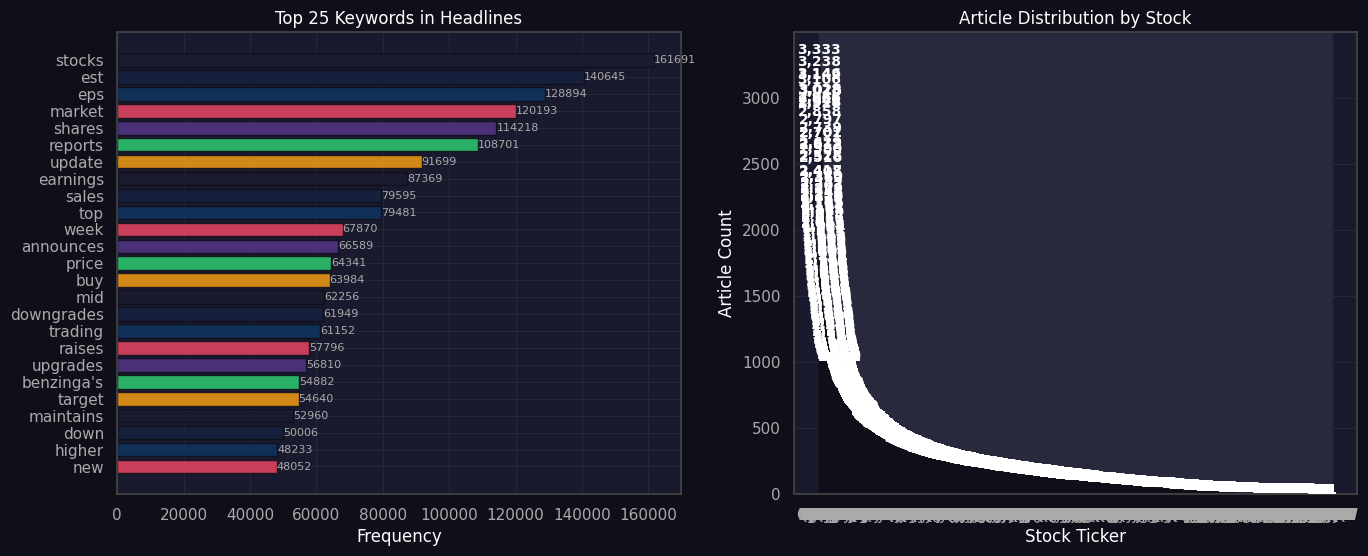

In [13]:
kw = top_keywords(df['headline'], top_n=25)
words_only  = [w for w,_ in kw]
freqs_only  = [f for _,f in kw]

stock_counts = df['stock'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
colors = [PALETTE[i % len(PALETTE)] for i in range(len(words_only))]
bars = ax.barh(words_only[::-1], freqs_only[::-1], color=colors[::-1], alpha=0.85, edgecolor='#0f0f1a')
ax.set_xlabel('Frequency'); ax.set_title('Top 25 Keywords in Headlines')
for bar, val in zip(bars, freqs_only[::-1]):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=8, color='#aaa')

ax = axes[1]
bars2 = ax.bar(stock_counts.index, stock_counts.values,
               color=[PALETTE[i % len(PALETTE)] for i in range(len(stock_counts))],
               alpha=0.88, edgecolor='#0f0f1a')
for bar, val in zip(bars2, stock_counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            f'{val:,}', ha='center', fontsize=10, color='white', fontweight='bold')
ax.set_xlabel('Stock Ticker'); ax.set_ylabel('Article Count')
ax.set_title('Article Distribution by Stock')

plt.show()


In [ ]:
stocks_list = sorted(df['stock'].unique())
n = len(stocks_list)

# Calculate rows and columns automatically
ncols = 4
nrows = (n + ncols - 1) // ncols   # rounds up to fit all stocks

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4.5))
axes = axes.flatten()

for idx, stock in enumerate(stocks_list):
    corpus = df[df['stock']==stock]['headline'].tolist()
    vec = TfidfVectorizer(stop_words='english', max_features=200, ngram_range=(1,2))
    X = vec.fit_transform(corpus)
    scores = X.mean(axis=0).A1
    terms  = vec.get_feature_names_out()
    top_idx = scores.argsort()[-10:][::-1]
    top_terms  = [terms[i] for i in top_idx]
    top_scores = [scores[i] for i in top_idx]

    ax = axes[idx]
    ax.barh(top_terms[::-1], top_scores[::-1],
            color=PALETTE[idx % len(PALETTE)], alpha=0.85, edgecolor='#0f0f1a')
    ax.set_title(stock, fontweight='bold', color=PALETTE[idx % len(PALETTE)], fontsize=13)
    ax.set_xlabel('Mean TF-IDF', fontsize=8)
    ax.tick_params(labelsize=8)

# Hide any leftover empty slots
for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()